# Adult Census Income Classification Project

**Ready-to-run on Google Colab or Kaggle**

No downloads or path configuration required.

The notebook automatically loads the Adult Census dataset from the UCI repository.


In [ ]:
# Install (safe if already installed)
!pip -q install scikit-learn pandas matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url="https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

cols=[
"age","workclass","fnlwgt","education","education-num",
"marital-status","occupation","relationship","race","sex",
"capital-gain","capital-loss","hours-per-week","native-country","income"
]

df=pd.read_csv(
    url,
    names=cols,
    skipinitialspace=True,
    na_values="?"
)

print(df.shape)
df.head()


(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Task 1 - Dataset Understanding

In [ ]:
display(df.info())
display(df.describe(include='all'))
display(df.isnull().sum())
display(df['income'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


None

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,32561.000000,30725,3.256100e+04,32561,32561.000000,32561,30718,32561,32561,32561,32561.000000,32561.000000,32561.000000,31978,32561
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


,count
income,
<=50K,24720
>50K,7841


## Exploratory Data Analysis

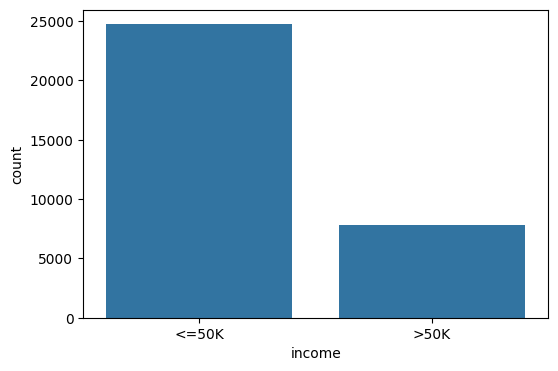

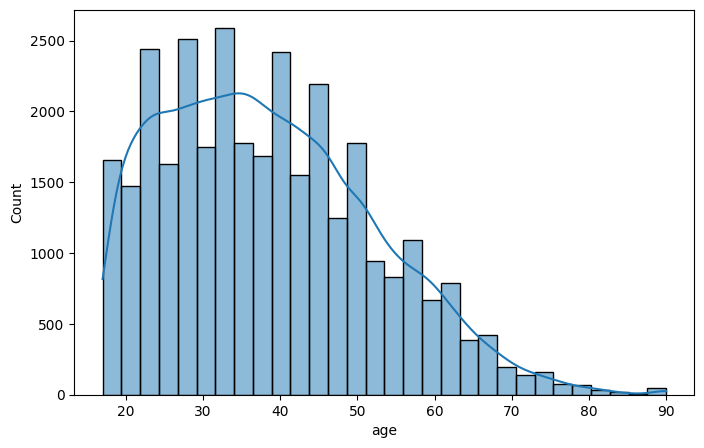

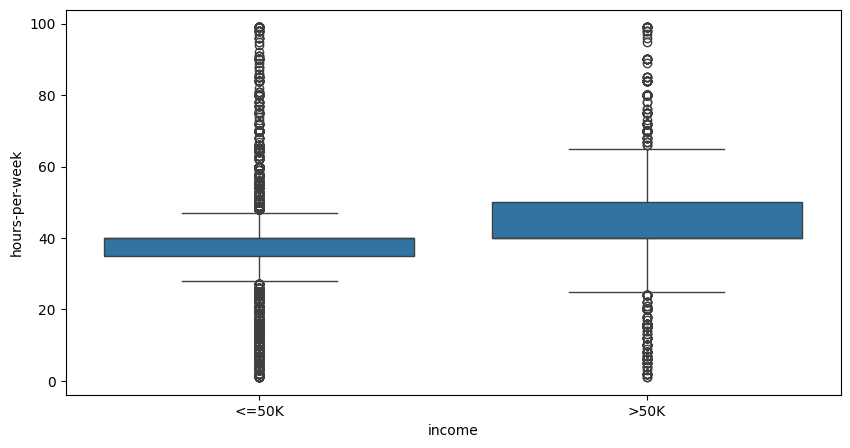

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='income')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['age'],bins=30,kde=True)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='income',y='hours-per-week')
plt.show()


## Task 2 - Data Cleaning

In [ ]:
df=df.dropna().copy()

X=df.drop(columns='income')
y=df['income']


## Task 3 - Feature Engineering

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer

num=X.select_dtypes(include=np.number).columns
cat=X.select_dtypes(exclude=np.number).columns

numeric=Pipeline([
('imp',SimpleImputer(strategy='median')),
('scale',StandardScaler())
])

categorical=Pipeline([
('imp',SimpleImputer(strategy='most_frequent')),
('onehot',OneHotEncoder(handle_unknown='ignore'))
])

pre=ColumnTransformer([
('num',numeric,num),
('cat',categorical,cat)
])

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42,stratify=y)


## Task 4 - Model Building

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models={
'Logistic Regression':LogisticRegression(max_iter=1000),
'Decision Tree':DecisionTreeClassifier(random_state=42),
'Random Forest':RandomForestClassifier(random_state=42,n_estimators=200),
'KNN':KNeighborsClassifier(),
'SVM':SVC(probability=True)
}


## Task 5 - Performance Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []
trained = {}

# Ensure labels have no leading/trailing spaces
y_train = y_train.str.strip()
y_test = y_test.str.strip()

positive = ">50K"

for name, model in models.items():

    pipe = Pipeline([
        ('prep', pre),
        ('model', model)
    ])

    # Train
    pipe.fit(X_train, y_train)
    trained[name] = pipe

    # Predictions
    pred = pipe.predict(X_test)
    pred = pd.Series(pred).str.strip()

    # Probabilities
    prob = pipe.predict_proba(X_test)[:, 1]

    # Store metrics
    results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, pos_label=positive),
        "Recall": recall_score(y_test, pred, pos_label=positive),
        "F1 Score": f1_score(y_test, pred, pos_label=positive),
        "ROC-AUC": roc_auc_score((y_test == positive).astype(int), prob)
    })

# Create results dataframe
results = pd.DataFrame(results)

# Sort by Accuracy
results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# Round numeric columns
numeric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results[numeric_cols] = results[numeric_cols].round(4)

# Display final comparison table
display(results)

,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.8498,0.7500,0.5952,0.6637,0.8983
1,Random Forest,0.8493,0.7286,0.6292,0.6752,0.9012
2,Logistic Regression,0.8475,0.7354,0.6052,0.6640,0.9022
3,KNN,0.8270,0.6664,0.6105,0.6372,0.8595
4,Decision Tree,0.8087,0.6134,0.6265,0.6199,0.7478


## Confusion Matrix (Best Model)

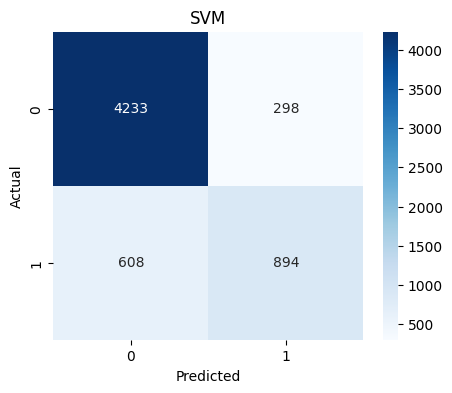

In [ ]:
best=results.iloc[0]['Algorithm']
pipe=trained[best]

pred=pipe.predict(X_test)

cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title(best)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Feature Importance (Random Forest)

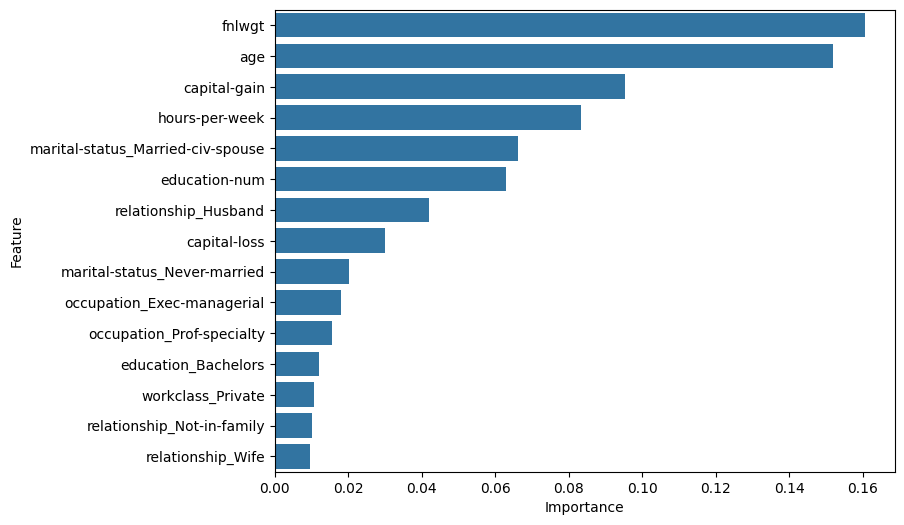

,Feature,Importance
1,fnlwgt,0.160643
0,age,0.151906
3,capital-gain,0.095380
5,hours-per-week,0.083362
31,marital-status_Married-civ-spouse,0.066288
2,education-num,0.062903
50,relationship_Husband,0.041932
4,capital-loss,0.029942
33,marital-status_Never-married,0.020246
39,occupation_Exec-managerial,0.018102


In [ ]:
rf=trained['Random Forest']

ohe=rf.named_steps['prep'].named_transformers_['cat'].named_steps['onehot']
feature_names=np.concatenate([
num,
ohe.get_feature_names_out(cat)
])

importances=rf.named_steps['model'].feature_importances_

imp=pd.DataFrame({
'Feature':feature_names,
'Importance':importances
}).sort_values('Importance',ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=imp,x='Importance',y='Feature')
plt.show()

imp
